In [1]:

import pandas as pd

In [3]:
df = pd.read_csv("Superstore_Data.csv", encoding="latin1")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             

In [4]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")

In [10]:
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)
df[["Order Date", "Ship Date"]].head()

datetime64[ns]
datetime64[ns]


,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [11]:
print("Duplicates:", df.duplicated().sum())
print("Negative Sales:", (df["Sales"] <= 0).sum())
print("Negative Quantity:", (df["Quantity"] <= 0).sum())
print("Discount range:", df["Discount"].min(), "-", df["Discount"].max())
print("Profit range:", df["Profit"].min(), "-", df["Profit"].max())

df["Category"] = df["Category"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()

df.to_csv("Superstore_clean.csv", index=False)
print("Saved. Final shape:", df.shape)

Duplicates: 0
Negative Sales: 0
Negative Quantity: 0
Discount range: 0.0 - 0.8
Profit range: -6599.978 - 8399.976
Saved. Final shape: (9994, 21)


In [12]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
aov = total_sales / total_orders
profit_margin = total_profit / total_sales

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value (AOV): ${aov:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Average Order Value (AOV): $458.61
Profit Margin: 12.47%


In [13]:
# Sales & Profit by Category
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
print(category_summary)

print("\n---\n")

# Sales & Profit by Region
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
print(region_summary)

print("\n---\n")

# Top 10 products by Sales
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008

---

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303

---

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 33

In [14]:
# Does discount level correlate with profit loss?
discount_profit = df.groupby("Category")[["Discount", "Profit"]].mean()
print(discount_profit)

print("\n---\n")

# Average discount by category
avg_discount = df.groupby("Category")["Discount"].mean().sort_values(ascending=False)
print(avg_discount)

print("\n---\n")

# Correlation between Discount and Profit
print("Correlation (Discount vs Profit):", df["Discount"].corr(df["Profit"]))

                 Discount     Profit
Category                            
Furniture        0.173923   8.699327
Office Supplies  0.157285  20.327050
Technology       0.132323  78.752002

---

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

---

Correlation (Discount vs Profit): -0.21948745637176834


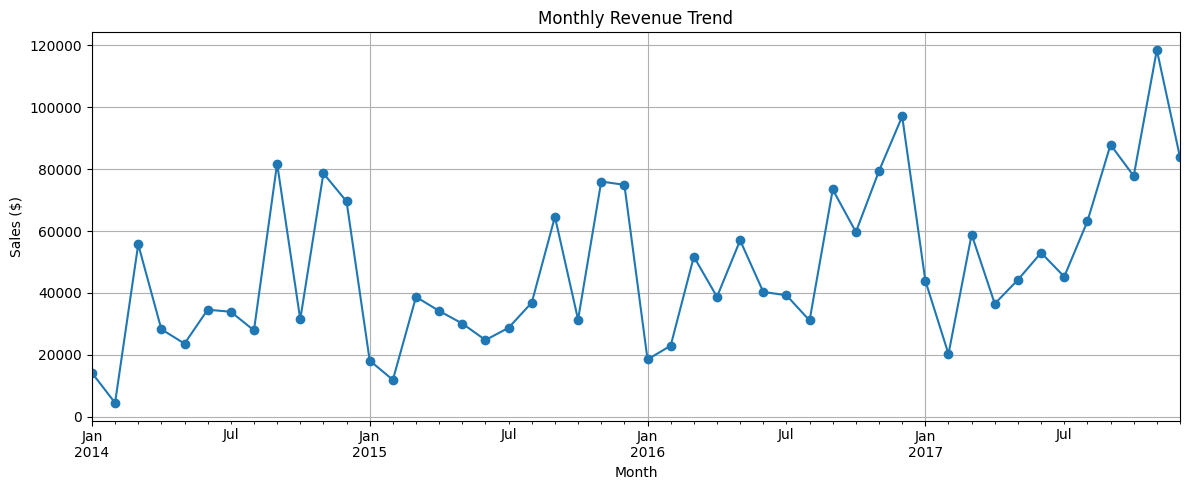

In [15]:
import matplotlib.pyplot as plt

# Monthly revenue trend
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png")
plt.show()

In [16]:
# Customer behavior: repeat vs one-time customers
customer_orders = df.groupby("Customer ID")["Order ID"].nunique()
repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

print(f"Repeat customers: {repeat_customers}")
print(f"One-time customers: {one_time_customers}")
print(f"Repeat purchase rate: {repeat_customers / customer_orders.shape[0]:.2%}")

print("\n---\n")

# Order patterns: which day of week gets most orders
df["Order Day"] = df["Order Date"].dt.day_name()
orders_by_day = df.groupby("Order Day")["Order ID"].nunique().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
print(orders_by_day)

print("\n---\n")

# Average items per order
avg_items = df.groupby("Order ID")["Quantity"].sum().mean()
print(f"Average items per order: {avg_items:.2f}")

print("\n---\n")

# Segment analysis
segment_summary = df.groupby("Segment")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)
print(segment_summary)

Repeat customers: 781
One-time customers: 12
Repeat purchase rate: 98.49%

---

Order Day
Monday       920
Tuesday      558
Wednesday    182
Thursday     746
Friday       916
Saturday     837
Sunday       850
Name: Order ID, dtype: int64

---

Average items per order: 7.56

---

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


In [17]:
# Sanity check: is Wednesday actually underrepresented, or is this a data quirk?
print(df["Order Date"].dt.day_name().value_counts())
print("\nTotal days in dataset by weekday:")
print(pd.Series(pd.date_range(df["Order Date"].min(), df["Order Date"].max())).dt.day_name().value_counts())

Order Date
Monday       1871
Friday       1818
Sunday       1710
Saturday     1655
Thursday     1463
Tuesday      1106
Wednesday     371
Name: count, dtype: int64

Total days in dataset by weekday:
Friday       209
Saturday     209
Sunday       208
Monday       208
Tuesday      208
Wednesday    208
Thursday     208
Name: count, dtype: int64


In [18]:
print(df["Order Date"].dt.day_name().value_counts())

Order Date
Monday       1871
Friday       1818
Sunday       1710
Saturday     1655
Thursday     1463
Tuesday      1106
Wednesday     371
Name: count, dtype: int64


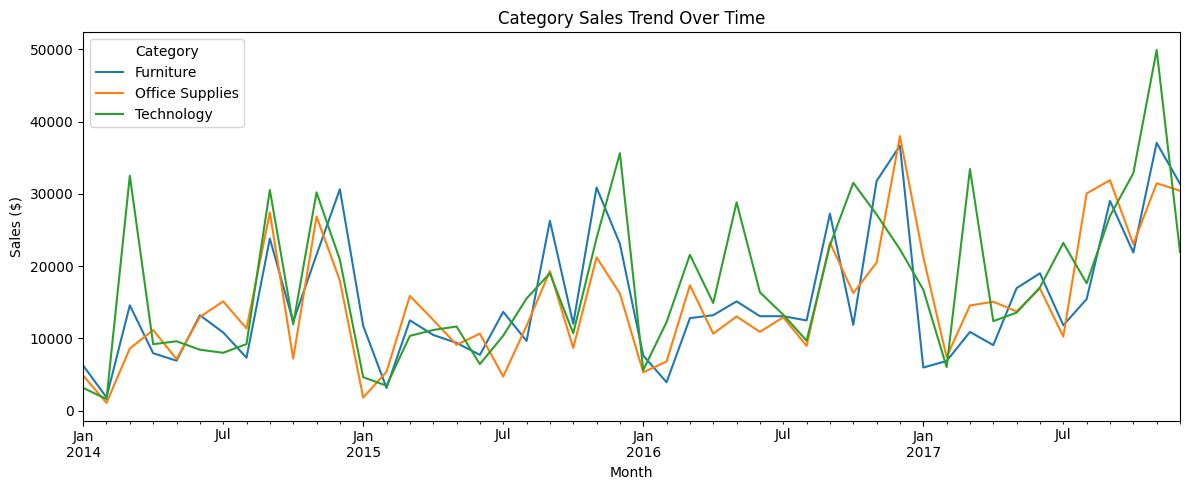

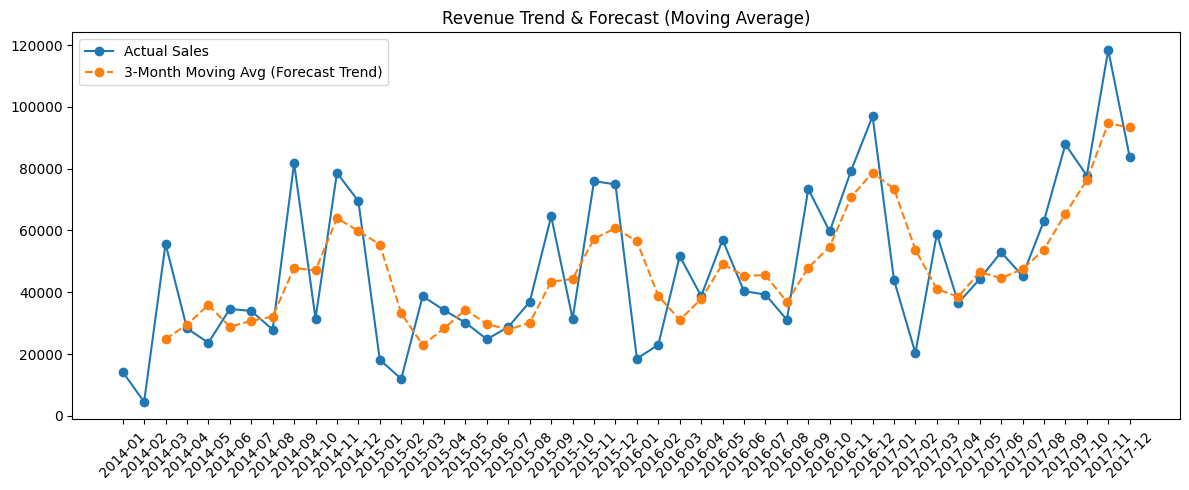

In [19]:
import seaborn as sns

# Product trend: category sales over time
category_trend = df.groupby([df["Order Date"].dt.to_period("M"), "Category"])["Sales"].sum().unstack()

plt.figure(figsize=(12,5))
category_trend.plot(ax=plt.gca())
plt.title("Category Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("category_trend.png")
plt.show()

# Revenue forecasting: 3-month moving average
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index()
monthly_sales.columns = ["Month", "Sales"]
monthly_sales["3-Month Moving Avg"] = monthly_sales["Sales"].rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Month"].astype(str), monthly_sales["Sales"], marker="o", label="Actual Sales")
plt.plot(monthly_sales["Month"].astype(str), monthly_sales["3-Month Moving Avg"], marker="o", linestyle="--", label="3-Month Moving Avg (Forecast Trend)")
plt.xticks(rotation=45)
plt.legend()
plt.title("Revenue Trend & Forecast (Moving Average)")
plt.tight_layout()
plt.savefig("revenue_forecast.png")
plt.show()

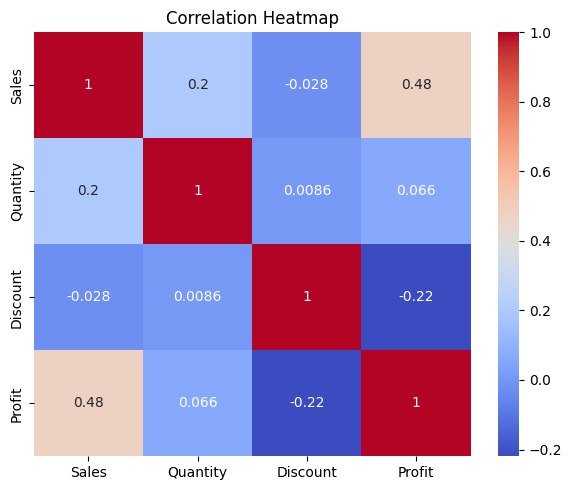

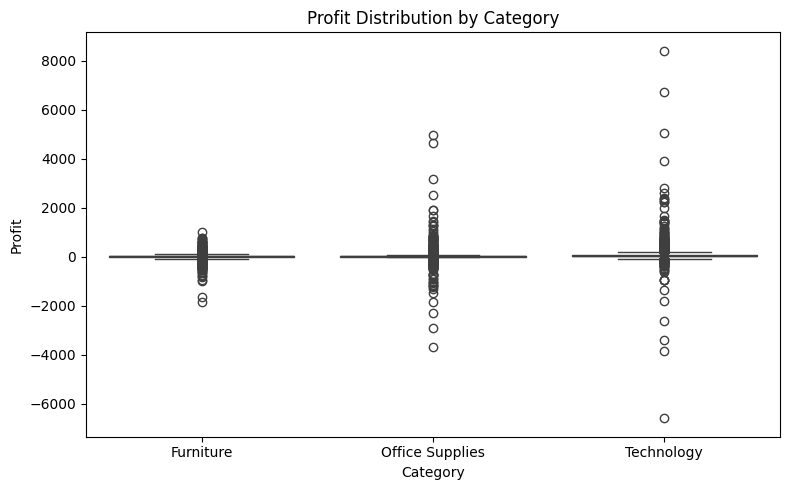

In [20]:
# Correlation heatmap - Seaborn
plt.figure(figsize=(6,5))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

# Boxplot - Profit distribution by Category
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Category", y="Profit")
plt.title("Profit Distribution by Category")
plt.tight_layout()
plt.savefig("profit_boxplot.png")
plt.show()

In [21]:
print(df["Order Date"].dt.day_name().value_counts())

Order Date
Monday       1871
Friday       1818
Sunday       1710
Saturday     1655
Thursday     1463
Tuesday      1106
Wednesday     371
Name: count, dtype: int64
